In [5]:
import sys
sys.path.append('../')
import scqubits as scq
import pandas as pd
import qutip as qt
import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import time, pytz, os, itertools, cmath
from datetime import datetime
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import scipy as sp
import utils_2Q_gate_zp as ut
from scipy.ndimage import gaussian_filter


In [6]:
truc_one_qubit, truc_tot, charge_pick = 300, 1000, True
truc_full = 1000

[hspace_full, eket_tot, eval_tot, n_theta0_dress, 
    n_theta1_dress, hspace_0, hspace_1, logi_state
    ] = ut.load_qubit_data_2q(truc_one_qubit, truc_full, charge_pick)

A1_bound, A2_bound, detune1_bound, detune2_bound = [
    (0.001, 0.5), (0.001, 0.5), (-0.5, 0.5), (-0.5, 0.5)    ]
tg_bound = (-0.001, 0.001) #(-1e-10, 1e-10) #

max_step_ideal, max_step_noisy = 3e-4, 1e-3 # Set max_step to 0 for parallel execution
option_ideal, option_noisy = ut.get_qutip_options(max_step_ideal, max_step_noisy) 

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
logi_state = ['0-0', '0-2', '2-0', '2-2']
# mid_state = '8-2'
# idx_0 = hspace_full.index('0-2')
# idx_1 = hspace_full.index('2-2')

mid_state = '0-8'
idx_0 = hspace_full.index('0-0')
idx_1 = hspace_full.index('0-2')

hspace_part = logi_state + [mid_state] + ['1-4', '8-0', '0-8', '2-8', ] # hspace_full[:200] # ut.truc_model['cnot_short_1000'][:200]

idx_2 = hspace_full.index(mid_state)
W_0_2 = eval_tot[idx_2] - eval_tot[idx_0]
W_1_2 = eval_tot[idx_2] - eval_tot[idx_1]
H0_full = qt.Qobj(np.diag(eval_tot))

index_part = [hspace_full.index(i) for i in hspace_part]
len_part = len(hspace_part)
H0_part = ut.truncate_2( H0_full, index_part)
n_theta0_part = ut.truncate_2(n_theta0_dress, index_part)
n_theta1_part = ut.truncate_2(n_theta1_dress, index_part)
logi_idx_part = [hspace_part.index(i) for i in logi_state]

state_full = [qt.basis(len_part, i) for i in range(len_part)]
# H_drive_part = [ H0_part,   [n_theta0_part, ut.drive_gauss_A],
#                             [n_theta0_part, ut.drive_gauss_B]  ]

H_drive_part = [ H0_part,   [n_theta1_part, ut.drive_gauss_A],
                            [n_theta1_part, ut.drive_gauss_B]  ]
c_op_list = []
num_cpus = 200
ratio = 3
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [49.99427378, 0.01920815, 0.02153711, 0.08851824, -0.07637073]
# [50, 0.114* ratio, 0.045* ratio, 0,0 ] 
# cnot
# [100.006167,0.053076,0.029316,-0.01188,-0.01157]
# [340.0063,0.016618,0.010608,-0.001774,-0.00169]
# x-gate
# [10.108462,0.41212,0.073451,-0.084451,-0.044706 ]
# [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 
# [119.917464,0.033248,0.00908,0.000489,0.000672]
 
arg_optimize = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': W_0_2 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': W_1_2 + 2*np.pi*detune_B,
            'gate_time': tg }
tlist = np.linspace(0, tg, num=int(tg))  # total time
logi_state_one = [0,2]

In [7]:
# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_part,
            qt.basis(len_part, hspace_part.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_full],
            args=pulse_args,
            options=qt.Options(store_states=True, num_cpus=num_cpus, nsteps=10000) )

2it [00:00,  3.34it/s]
2it [00:00,  2.50it/s]


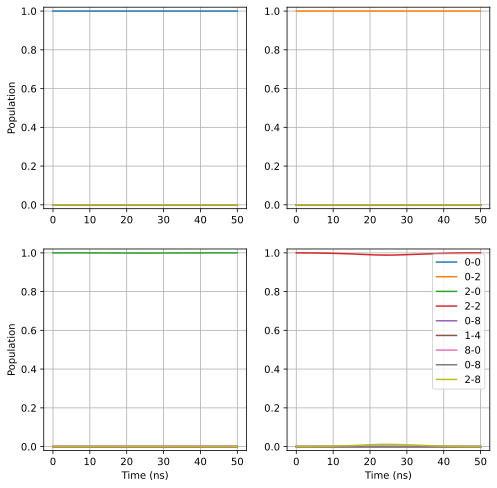

In [8]:
fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
# fig.suptitle(f"CNOT (tg={tg:.0f}, $|8,2\\rangle$, logF={fidelity_full:.3f}, $N_{{\\rm state}}$={truc1})", fontsize=16, y=0.92)
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_part, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            # if np.max(y_pop) > 0.01:
            ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
ax[1][1].legend()


In [9]:
def optimize_population(arg_optimize, *args):
    [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = arg_optimize
    [H_drive_part, W_0_2, W_1_2, num_cpus] = args   

    pulse_args = {'drive_amp_A': drive_amp_A ,
                'drive_freq_A': W_0_2 + 2*np.pi*detune_A,
                'drive_amp_B': drive_amp_B ,
                'drive_freq_B': W_1_2 + 2*np.pi*detune_B,
                'gate_time': tg }
    tlist = np.linspace(0, tg, num=int(tg))  # total time    

    result = {}
    for idx, state_i in enumerate(logi_state_one):
        for jdx, state_j in enumerate(logi_state_one):
            # This simulation is just for viewing the affect of the pulse
            result[idx, jdx] = qt.mesolve(
                H_drive_part,
                qt.basis(len_part, hspace_part.index( str(state_i) +'-'+str(state_j) )),
                tlist,
                e_ops=[state * state.dag() for state in state_full],
                args=pulse_args,
                options=qt.Options(store_states=True, num_cpus=num_cpus, nsteps=10000) )    
            
    p00 = result[0,0].expect[1][-1] # population in |0,2>
    p02 = result[0,1].expect[0][-1]
    p20 = result[1,0].expect[3][-1]
    p22 = result[1,1].expect[2][-1]

    return  (np.log10(1- p00) + np.log10(1- p02) + np.log10(1- p20) + np.log10(1- p22))       


state_full = [qt.basis(len_part, i) for i in range(4)]
tg_bound = (-0.01, 0.01) #(-1e-10, 1e-10) #
A1_bound, A2_bound, detune1_bound, detune2_bound = [
    (0.001, 0.5), (0.001, 0.5), (-0.1, 0.1), (-0.1, 0.1)     ]

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
num_cpus = 1

arg_truc = [H_drive_part, W_0_2, W_1_2, num_cpus]

tg_bounds = (tg+tg_bound[0], tg+tg_bound[1])
bounds = (tg_bounds, A1_bound, A2_bound, detune1_bound, detune2_bound)
res = sp.optimize.differential_evolution(
    func=optimize_population,
    bounds=bounds,
    args=arg_truc,
    disp=True,
    callback=ut.print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False, # 'True' will make the for-loop break
    )

print(res, '\n')

 /home/zlqed/anaconda3/envs/qutip4/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.0057
----------------------------
differential_evolution step 2: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.0075
----------------------------
differential_evolution step 3: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.0086
----------------------------
differential_evolution step 4: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.0097
----------------------------
differential_evolution step 5: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.0109
----------------------------
differential_evolution step 6: f(x)= -2.36925
Best Solution: [49.98704761, 0.32540603, 0.24773818, 0.07618416, 0.05213717]
Convergence: 0.01

In [10]:
def get_propagator(H, tlist, num_cpus, c_op_list, pulse_args, logi_idx, option_ideal=None, option_noisy=None):
    """
    Compute the propagator for a quantum system, supporting both noiseless and noisy systems.

    Args:
        H (list or qt.Qobj): The Hamiltonian of the system. Can be a single Qobj or a list where
                             the first element represents the static part.
        tlist (list): List of time points for the simulation.
        num_cpus (int): Number of CPUs to use for parallel computation (if `parallel=True`).
        c_op_list (list): List of collapse operators for modeling noise. If empty, the system is noiseless.
        pulse_args (dict): Arguments for time-dependent pulse functions in the Hamiltonian.
        option_ideal, option_noisy (qt.Options): Solver options for QuTiP.
        logi_idx (list): List of logical states (indices of basis states) to include in the propagator.

    Returns:
        qt.Qobj or list of qt.Qobj:
            - For noiseless systems: A `Qobj` representing the truncated propagator for logical states.
            - For noisy systems: A `Qobj` representing the superoperator propagator for the final time step.
    """
    dimz = len(logi_idx)
    H0 = H[0][0] if isinstance(H[0], list) else H[0] if isinstance(H, list) else H
    if len(c_op_list) == 0:

        N = H0.shape[0]
        if num_cpus > 1:
            u = np.zeros([N, dimz, len(tlist)], dtype=complex)
            output = qt.parallel.parallel_map(parallel_sesolve, logi_idx,
                                    task_args=(N, H, tlist, pulse_args, option_ideal),
                                    num_cpus=num_cpus)
            for n in range(dimz):
                for k, t in enumerate(tlist):
                    u[:, n, k] = output[n].states[k].full().T
            prop = [qt.Qobj(u[:, :, k], dims=[[[N], [N]], [[dimz], [dimz]]]) for k in range(len(tlist))][-1]
            return truncate_2(prop, logi_idx)
        else:
            # Computes the propagator for noiseless systems.
            prop = np.zeros((H0.shape[0], dimz), dtype=np.complex128)
            for i in logi_idx:
                res = qt.sesolve(H, qt.basis(H[0].shape[0], i), tlist, options=option_ideal, args=pulse_args)
                prop[:, logi_idx.index(i)] = res.states[-1].full().flatten()
            Uc = truncate_2(qt.Qobj(prop), logi_idx)
            return Uc

    else: # noise

        # Computes the propagator for noisy systems.
        proj_idx = [(i, j) for j in logi_idx for i in logi_idx]
        N = H0.shape[0]
        u = np.zeros([N * N, dimz * dimz, len(tlist)], dtype=complex)

        if num_cpus > 1:
            output = qt.parallel.parallel_map(
                parallel_mesolve, range(dimz * dimz),
                task_args=(N, H, tlist, c_op_list, pulse_args, option_noisy, proj_idx),
                task_kwargs={"dims": H0.dims}, num_cpus=num_cpus
            )
            for n in range(dimz * dimz):
                for k, t in enumerate(tlist):
                    u[:, n, k] = qt.superoperator.mat2vec(output[n].states[k].full()).T
        else:
            for n, idx in enumerate(proj_idx):
                row_idx, col_idx = idx
                rho0 = qt.states.projection(N, row_idx, col_idx)
                rho0.dims = H0.dims
                output = qt.mesolve(
                    H, rho0, tlist, c_op_list, args=pulse_args, options=option_noisy, _safe_mode=False
                )
                for k, t in enumerate(tlist):
                    u[:, n, k] = qt.superoperator.mat2vec(output.states[k].full()).T

        return [qt.Qobj(u[:, :, k], dims=[[[N], [N]], [[dimz], [dimz]]]) for k in range(len(tlist))][-1]

def XI_fidelity_log(arg_all):
    [tg, drive_amp_A, drive_amp_B, detune_A, detune_B,
     H_qbt_drive, w_0_2, w_1_2, num_cpus, c_op_list, logi_idx, 
     mid_state, option_ideal, option_noisy] = arg_all
    pulse_args = {'drive_amp_A': drive_amp_A ,
                'drive_freq_A': w_0_2 + 2*np.pi*detune_A,
                'drive_amp_B': drive_amp_B ,
                'drive_freq_B': w_1_2 + 2*np.pi*detune_B,
                'gate_time': tg }
    tlist = np.linspace(0, tg, num=10*int(tg))  # total time

    propagator = get_propagator(H_qbt_drive, tlist, num_cpus, c_op_list, pulse_args, 
                          logi_idx, option_ideal, option_noisy)

    fidelity = get_fidelity_super_operator(propagator, logi_idx, XI, c_op_list, mid_state)
    
    return np.log10(1-fidelity)


def XI_fidelity_log_noise(arg_optimize, *args):
    [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = arg_optimize
    [H_qbt_drive, w_0_2, w_1_2, num_cpus, c_op_list, logi_idx, 
     mid_state, option_ideal, option_noisy] = args

    arg_all = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B,
     H_qbt_drive, w_0_2, w_1_2, num_cpus, c_op_list, logi_idx, 
     mid_state, option_ideal, option_noisy]

    return XI_fidelity_log(arg_all)

def XI_phase_correct(U_kraus):
    U_final = [] 
    for prop in U_kraus:    
        prop = qt.Qobj(prop, dims=[[2, 2], [2, 2]]) 
        Uc_prime = swap()* prop* swap() # for |45> state
        phase = np.angle(Uc_prime)
        x1 = - phase[0,2]
        x2 = - phase[3,1]
        U_bef = qt.Qobj(np.diag([1, np.exp(1j* x1), np.exp(1j* x2), np.exp(1j* (x1+x2))])
                , dims=[[2, 2], [2, 2]])
        U_final.append(np.exp(-1j* phase[2,0])* Uc_prime* U_bef)
    return U_final

In [11]:
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 
x0 = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
# [25.020473,0.180208,0.046132,-0.003789,0.001544 ] 

tg_bound = (-0.01, 0.01) #(-1e-10, 1e-10) #
A1_bound, A2_bound, detune1_bound, detune2_bound = [
    (0.001, 0.5), (0.001, 0.5), (-0.5, 0.5), (-0.5, 0.5)     ]

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
num_cpus = 1

arg_truc = [H_drive_part, W_0_2, W_1_2, num_cpus, c_op_list, 
            logi_idx_part, mid_state, option_ideal, option_noisy]

tg_bounds = (tg+tg_bound[0], tg+tg_bound[1])
bounds = (tg_bounds, A1_bound, A2_bound, detune1_bound, detune2_bound)
res = sp.optimize.differential_evolution(
    func=ut.XI_fidelity_log_noise,
    bounds=bounds,
    args=arg_truc,
    disp=True,
    callback=ut.print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    x0=x0,
    polish=False, # 'True' will make the for-loop break
    )

print(res, '\n')



differential_evolution step 1: f(x)= -0.145299
Best Solution: [25.01585436, 0.12752504, 0.26112662, -0.10641464, -0.06486127]
Convergence: 0.1158
----------------------------
differential_evolution step 2: f(x)= -0.160413
Best Solution: [25.01556619, 0.35024696, 0.27591923, -0.30522827, -0.30510093]
Convergence: 0.083
----------------------------
differential_evolution step 3: f(x)= -0.160413
Best Solution: [25.01556619, 0.35024696, 0.27591923, -0.30522827, -0.30510093]
Convergence: 0.0821
----------------------------
differential_evolution step 4: f(x)= -0.165124
Best Solution: [25.01538621, 0.42226245, 0.3566554, -0.2194513, -0.20013681]
Convergence: 0.0681
----------------------------
differential_evolution step 5: f(x)= -0.196207
Best Solution: [25.01320941, 0.33968508, 0.25982933, -0.18398339, -0.13686409]
Convergence: 0.0523
----------------------------
differential_evolution step 6: f(x)= -0.196207
Best Solution: [25.01320941, 0.33968508, 0.25982933, -0.18398339, -0.13686409]
Co